# RealModel Exercise – CMIP6 future temperature projections

### Background: What is CMIP6?
In this short exercise, you will work with real Earth system model (ESM) data. The different ESMs used here all participate in the Coupled Model Intercomparison Project - Phase 6 (CMIP6), and are used by the Intergovernmental Panel on Climate Change (IPCC) to inform statements about the physical state of the climate and future global warming.  

CMIP6 is a project which coordinates experiments with ESMs across modelling centers. In order to participate, modelling centers (a modelling center typically operates one ESM) have to conduct specific, controlled experiments with their ESM. The setup of these experiments is identical for all participating ESMs. This allows scientists to analyze data from different ESMs which is comparable, because the experimental setup was identical. 

Such experiments could be, for example, simulating the historical climate from 1850 until 2014. All modelling centers then run their ESM with pre-defined boundary conditions as external forcing (for example, precise solar radiation, volcanic eruptions, greenhouse-gas emissions, etc.). The forcing data is provided by CMIP6 and is, of course, identical for all participating ESMs. 

### Your Task
Here, we provide you with annual global surface air temperature (GSAT) data from 20 ESMs participating in CMIP6. The data consist of a minimum of 5 ensemble members per model. The ensemble members are a historical experiment spanning 1850-2014, smoothly continued by a scenario simulation from 2015 until 2100, under the so-called SSP2-4.5 scenario. 

Your ultimate task will be to make a so-called "emergent constraint" based on this data, which tells policy makers how much warming to expect by the end of the century, if we follow a SSP2-4.5 scenario. 

Don't worry if the concept of an emergent constraint is not clear to you at this point. By following the step-by-step guide in the Jupyter Notebook, you should be able to grasp the concepts and execute the exercise. 

This exercise is strongly based on existing work done with emergent constraints, in particular: 
- Tokarska KB, Stolpe MB, Sippel S, Fischer EM, Smith CJ, Lehner F, Knutti R. Past warming trend constrains future warming in CMIP6 models. Sci Adv. 2020 Mar 18;6(12):eaaz9549. doi: 10.1126/sciadv.aaz9549. PMID: 32206725; PMCID: PMC7080456.

Whenever you feel stuck and are unsure how to answer some of the questions, especially those requiring interpretation of your results, we recommend reading the Tokarska et al. (2020) study. 

### Have fun!

----------------------------------------------------------------------------------

# Start

We provide you with a pd.DataFrame object (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) containing the relevant GSAT data for this exercise. Execute all existing code cells and fill out code cells marked with #TODO. Answer text questions in raw, also marked with TODO. We recommend you to work with pandas dataframes throughout the exercise, as this allows easy storage of metadata (such as Model, Year, etc.) together with the actual data we care about (GSAT). 


In [2]:
import pandas as pd
import numpy as np
import os
import xarray as xr
import pickle
from tqdm import tqdm
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl

In [3]:
# Set the path to the data directory
datapath = 'data/'

# Load dataframe with cmip6 sufrace temperature data
with open(f'{datapath}cmip6_surface_temperature_5mems.pkl', 'rb') as file: 
    df_temp = pickle.load(file)


### 1. Temperature change in ESMs
First, familiarize yourselves with the dataframe structure (Hint: pd.DataFrame.head(n) shows the top n rows of a pandas DataFrame). 
 

In [4]:
display(df_temp.head())
display(df_temp.shape)

,Temperature,Model,run,Year
0,13.869604,ACCESS-CM2,r1i1p1f1,1850
1,13.878343,ACCESS-CM2,r1i1p1f1,1851
2,14.029950,ACCESS-CM2,r1i1p1f1,1852
3,13.932634,ACCESS-CM2,r1i1p1f1,1853
4,14.001171,ACCESS-CM2,r1i1p1f1,1854


(86846, 4)

The dataframe contains a column containing the GSAT, a column indicating which ESM this is, another column with a string indicating the precise ensemble member, and a column with the simulation year. You can also print out all unique elements of a column like this:

In [15]:
# See what ESMs are present in the dataset
pd.Series(df_temp.Model.unique())

0          ACCESS-CM2
1       ACCESS-ESM1-5
2               CESM2
3          CNRM-CM6-1
4         CNRM-ESM2-1
5             CanESM5
6       EC-Earth3-Veg
7           EC-Earth3
8         GISS-E2-1-G
9     HadGEM3-GC31-LL
10       IPSL-CM6A-LR
11         MIROC-ES2L
12             MIROC6
13      MPI-ESM1-2-LR
14         MRI-ESM2-0
15        UKESM1-0-LL
16        GISS-E2-1-H
17       EC-Earth3-CC
18        GISS-E2-2-G
19          CanESM5-1
dtype: object

In Figure 1 below, you can see the the model output for 20 ESMs for the historical period until 2014 and the future SSP2-4.5 projection until 2100. The thick colored lines show the ensemble mean (average across all runs of an ESM), the shading shows the minimum and maximum of the ensemble.

(NOTE: The function sns.lineplot() automatically displays the mean across a group (thick line). The grouping variable can be specified with the argument 'hue' in the function. See https://seaborn.pydata.org/generated/seaborn.lineplot.html )

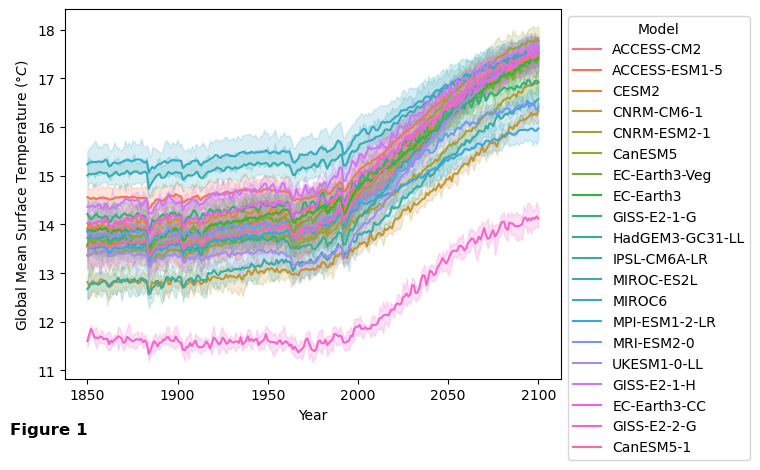

In [6]:
# Visualize data
ax = sns.lineplot(df_temp, x='Year', y='Temperature', hue='Model', errorbar=('pi',100))
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_ylabel('Global Mean Surface Temperature $(\degree C)$')
plt.suptitle('Figure 1',
             x=0.1, y=0.02, fontsize=12, fontweight='bold')

plt.show()

__1.a) What are the three hottest models by the end of the 21st century?__

Hint 1: you can use the function pd.DataFrame.groupby() to group your dataframe by a specific variable and compute statistics like the mean. The function pd.Series.sort_values() allows you to sort a series in ascending or descending order.

Hint 2: Think about what a good definition of "end of century" is and choose your own. Is looking at the year 2100 enough?

In [34]:
#compute the average mean per year
average_temp_models=(df_temp.groupby(["Model","Year"],as_index=False)["Temperature"].mean())
#since end of century estimates at 2100 are point estimations we want to define an interval we define an interval 
end_of_century_models=average_temp_models[average_temp_models["Year"].between(2091,2100)]
hottest_models=end_of_century_models.groupby(["Model"])["Temperature"].mean().sort_values(ascending=False)
hottest_models.head(3)


Model
CanESM5          17.746506
GISS-E2-1-H      17.590860
ACCESS-ESM1-5    17.579692
Name: Temperature, dtype: float64

__1.b) We now want to look at anomalies with respect to the reference period 1981-2014, instead of the raw data. Compute the anomalies with respect to this period and reproduce the plot from Figure 1 by replacing the raw data with the anomalies.__

Hint: Start by computing the reference period temperatures for each model and creating a column which stores them. Then subtract this from the raw temperature to obtain anomalies.

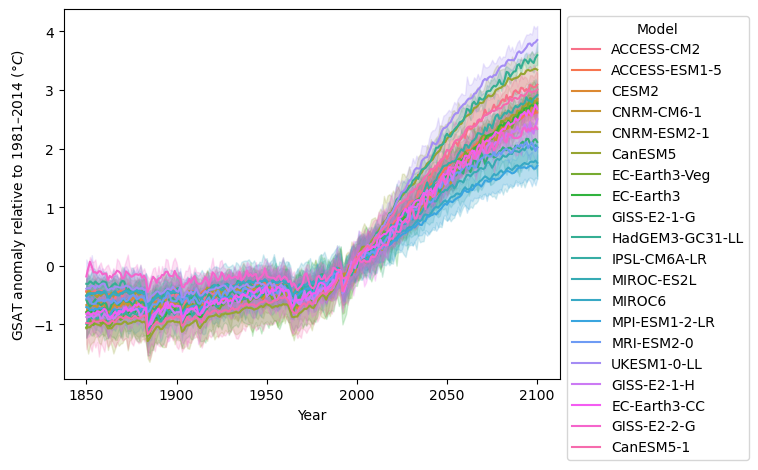

In [53]:
reference_period=df_temp[df_temp["Year"].between(1981,2014)]
ref_temp= reference_period.groupby("Model")["Temperature"].mean().rename("Reference Temperature")

total_df=df_temp.merge(ref_temp,on="Model")
#temp_anomalies=reference_period["Temperature"]-
total_df["Anomaly"]=(total_df["Temperature"]-total_df["Reference Temperature"])
total_df.head()

ax = sns.lineplot(total_df, x="Year", y="Anomaly", hue="Model", errorbar=("pi", 100))
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_ylabel("GSAT anomaly relative to 1981–2014 $(\\degree C)$")
plt.show()


__1.c) What are the three hottest models at the end of the 21st century when we look at GSAT anomalies with respect to 1981–2014 instead of the raw data?__ 

In [67]:
#do the same as in a

new_average_temp_mean=total_df.groupby(["Model","Year"],as_index=False)["Anomaly"].mean()
#select time
sel_period=new_average_temp_mean[new_average_temp_mean["Year"].between(2081,2100)]
new_hottest_models=sel_period.groupby(["Model"])["Anomaly"].mean().sort_values(ascending=False)
new_hottest_models.head(3)


Model
UKESM1-0-LL        3.634117
HadGEM3-GC31-LL    3.389385
CanESM5            3.245680
Name: Anomaly, dtype: float64

__1.d) Consider the third hottest model in the raw GSAT ranking from 1.a. How did its ranking change when you transformed the data to anomalies?__



In [76]:
print("Raw GSAT rank:",hottest_models.index.get_loc("ACCESS-ESM1-5") + 1)
print("Anomaly rank", new_hottest_models.index.get_loc("ACCESS-ESM1-5")+1)

Raw GSAT rank: 3
Anomaly rank 13


__1.e) Explain why it makes more sense to look at anomalies with respect to a reference period rather than absolute warming when comparing temperature projections by different ESMs.__


### 2. Relationship between historical and future warming


__From now on we will only work with the anomalies you computed in 1.c).__

__2.a) Each ESM ensemble consists of several members, each member being a possible realization of the future. Computing the ensemble mean across all members of an ESM provides a single projection per ESM. What type of uncertainty is reduced by taking the average across ensemble members?__

__2.b) How does the variance scale with the number of members considered? Let's take a brief detour and test this__
- (i) Select the model containing the most members (or at least more than 30)
- (ii) Calculate the anomalies of each member of the selected model with respect to the mean of the ensemble member in the 1981-2014 period

Hint: It might be useful to restructure the data into a matrix, something like rows=Year, columns=run, values=Anomaly

model with most members: MIROC6 with the number of members: 50


run,r10i1p1f1,r11i1p1f1,r12i1p1f1,r13i1p1f1,r14i1p1f1,r15i1p1f1,r16i1p1f1,r17i1p1f1,r18i1p1f1,r19i1p1f1,...,r47i1p1f1,r48i1p1f1,r49i1p1f1,r4i1p1f1,r50i1p1f1,r5i1p1f1,r6i1p1f1,r7i1p1f1,r8i1p1f1,r9i1p1f1
Year,,,,,,,,,,,,,,,,,,,,,
1850,-0.538445,-0.282285,-0.506709,-0.495365,-0.607599,-0.459515,-0.606947,-0.726704,-0.541833,-0.431653,...,-0.548055,-0.714931,-0.321403,-0.264417,-0.558714,-0.612242,-0.585540,-0.782237,-0.486433,-0.617500
1851,-0.341237,-0.745543,-0.382116,-0.507118,-0.658403,-0.442829,-0.568179,-0.626683,-0.483988,-0.477925,...,-0.525815,-0.544069,-0.182514,-0.184497,-0.441566,-0.634908,-0.581328,-0.690347,-0.541677,-0.631350
1852,-0.215674,-0.709085,-0.460407,-0.453709,-0.465006,-0.496185,-0.573528,-0.399843,-0.480884,-0.370536,...,-0.463397,-0.441827,-0.136660,-0.518101,-0.248582,-0.630011,-0.598978,-0.527808,-0.568629,-0.627423
1853,-0.561719,-0.649945,-0.355227,-0.395713,-0.324919,-0.465538,-0.502905,-0.323936,-0.555620,-0.357723,...,-0.350247,-0.527084,-0.535212,-0.664835,-0.512724,-0.610642,-0.488675,-0.605623,-0.664754,-0.590535
1854,-0.599631,-0.566019,-0.650630,-0.374060,-0.066123,-0.239958,-0.561579,-0.534566,-0.459267,-0.417704,...,-0.411229,-0.612261,-0.546198,-0.621643,-0.619154,-0.565008,-0.529675,-0.632593,-0.607139,-0.380226


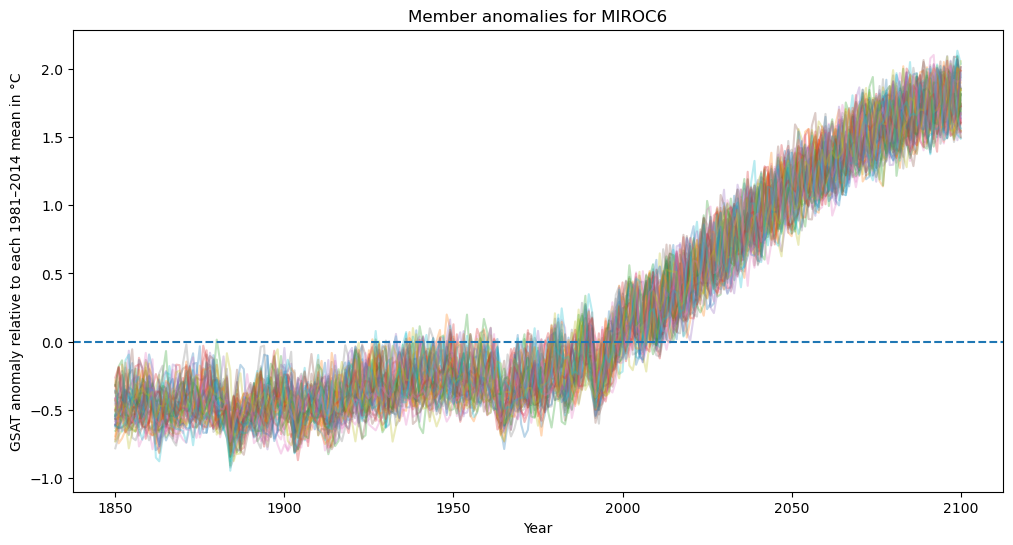

In [125]:
#(i) select model with the most amount of members

member_counts=df_temp.groupby("Model")["run"].nunique().sort_values(ascending=False)
sel_model=member_counts.index[0] #for a tie this only picks the first one

print("model with most members:", sel_model, "with the number of members:", member_counts.iloc[0])

#extract data from this model:
df_sel=df_temp[df_temp["Model"]==sel_model].copy()

#(ii)compute anomalies of each member
ref_member=df_sel[df_sel["Year"].between(1981,2014)].groupby("run")["Temperature"].mean().rename("Reference Temperature")
df_sel=df_sel.merge(ref_member, on="run", how="left")
df_sel["Anomaly"]=df_sel["Temperature"]-df_sel["Reference Temperature"]

#restructure into a matrix with rows=Year, columns=run and values=Anomaly
anomaly_matrix=df_sel.pivot(index="Year",columns="run", values="Anomaly")
display(anomaly_matrix.head())


#for visual representation plot the anomalies:
plt.figure(figsize=(12, 6))
for run in anomaly_matrix.columns:
    plt.plot(anomaly_matrix.index, anomaly_matrix[run], alpha=0.3)
plt.axhline(0, linestyle="--")
plt.title(f"Member anomalies for {sel_model}")
plt.ylabel("GSAT anomaly relative to each 1981–2014 mean in °C")
plt.xlabel("Year")
plt.show()

__2.c) Use a Monte Carlo simulation approach__
- For each ensemble size  
   \( N = 1, 2, ..., M \) where M is the total number of ensemble members:

   - Randomly select **\(N\) ensemble members** (with or without replacement, your choice).
   - Compute the **ensemble mean time series** across the selected members.
   - Calculate the **sample variance over time** of this ensemble mean.

- Repeat the experiment 200 times for each ensemble size \(N\).

- For each ensemble size, compute the **median variance** across all repetitions.

- Plot the **median variance of the ensemble-mean time series as a function of ensemble size \(N\)** and compare it with the **theoretical \(1/N\) reference curve**, scaled to match the variance at \(N=1\). This allows you to assess whether the reduction in variance with increasing ensemble size follows the expected \(1/N\) behavior.


,N,median_variance,reference_values_1_over_N
0,1,0.621460,0.621460
1,2,0.612851,0.310730
2,3,0.612377,0.207153
3,4,0.607432,0.155365
4,5,0.607669,0.124292


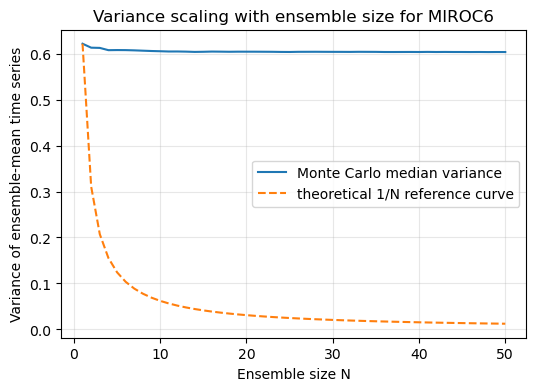

In [119]:
# random number generator

rng=np.random.default_rng(55)
max_ensemble_size=anomaly_matrix.shape[1]
n_rand_samples=200 #num of times we respeat the random sampling experiment for each ensemble size

#store in results:
res=[]

for N in range(1,max_ensemble_size+1):
    variances=[]

    for _ in range(n_rand_samples): 
        sampled_runs = rng.choice(anomaly_matrix.columns,size=N,replace=False) 
        ensemble_mean=anomaly_matrix[sampled_runs].mean(axis=1)
        var_time=ensemble_mean.var()
        variances.append(var_time)
    res.append({"N": N, "median_variance": np.median(variances)})

#convert results to dataframe for easier plotting and computations
results_df=pd.DataFrame(res)

#extract variance of N=1 for theoretical plot as reference curve:
var_n_1 = results_df.loc[results_df["N"] == 1, "median_variance"].iloc[0]
results_df["reference_values_1_over_N"] = var_n_1 / results_df["N"]

#plotting of the results
#show results of the table:
display(results_df.head()) 

#now plotting:
plt.figure(figsize=(6,4))
plt.plot(results_df["N"],results_df["median_variance"],label="Monte Carlo median variance")  

#1/N plot as a reference
plt.plot(results_df["N"],results_df["reference_values_1_over_N"],linestyle="--",label="theoretical 1/N reference curve")  
plt.xlabel("Ensemble size N")
plt.ylabel("Variance of ensemble-mean time series")
plt.title(f"Variance scaling with ensemble size for {sel_model}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

__2.d) Does the result look correct? If it does not, why? Can you think of any component we missed that can create a difference compared to the theoretical trend? Try to identify the mistake and replot the result!__

Hint: If you are stuck, continue with 2.e) and revisit this exercise afterward.



,N,median_variance,reference_values_1_over_N
0,1,0.023817,0.023817
1,2,0.011554,0.011908
2,3,0.007482,0.007939
3,4,0.005541,0.005954
4,5,0.004378,0.004763


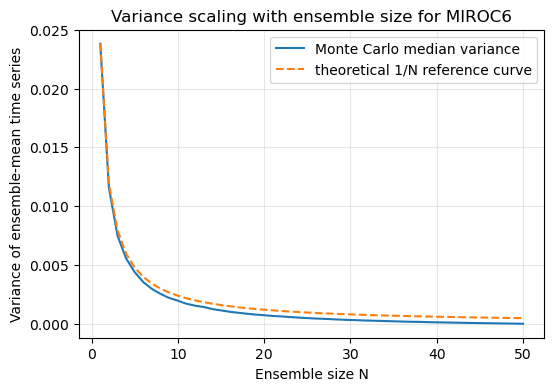

In [121]:
#we know: epsilon_i(t)=anomaly_i(t)-forcing(t)
#estimate the forcing response by avera
forcing=anomaly_matrix.mean(axis=1)
internal_var_matrix=anomaly_matrix.sub(forcing,axis=0)

#now same procedure as before on internal_var_matrix instead of the anomaly_matrix
rng=np.random.default_rng(55)
max_ensemble_size=internal_var_matrix.shape[1]
n_rand_samples=200 #num of times we respeat the random sampling experiment for each ensemble size

#store in results:
res=[]

for N in range(1,max_ensemble_size+1):
    variances=[]

    for _ in range(n_rand_samples): 
        sampled_runs = rng.choice(internal_var_matrix.columns,size=N,replace=False) 
        ensemble_mean=internal_var_matrix[sampled_runs].mean(axis=1)
        var_time=ensemble_mean.var()
        variances.append(var_time)
    res.append({"N": N, "median_variance": np.median(variances)})

#convert results to dataframe for easier plotting and computations
results_df=pd.DataFrame(res)

#extract variance of N=1 for theoretical plot as reference curve:
var_n_1 = results_df.loc[results_df["N"] == 1, "median_variance"].iloc[0]
results_df["reference_values_1_over_N"] = var_n_1 / results_df["N"]

#plotting of the results
#show results of the table:
display(results_df.head()) 

#now plotting:
plt.figure(figsize=(6,4))
plt.plot(results_df["N"],results_df["median_variance"],label="Monte Carlo median variance")  

#1/N plot as a reference
plt.plot(results_df["N"],results_df["reference_values_1_over_N"],linestyle="--",label="theoretical 1/N reference curve")  
plt.xlabel("Ensemble size N")
plt.ylabel("Variance of ensemble-mean time series")
plt.title(f"Variance scaling with ensemble size for {sel_model}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

__2.e) Compute the ensemble mean GSAT for all ESMs and plot its evolution from 1850 to 2100.__

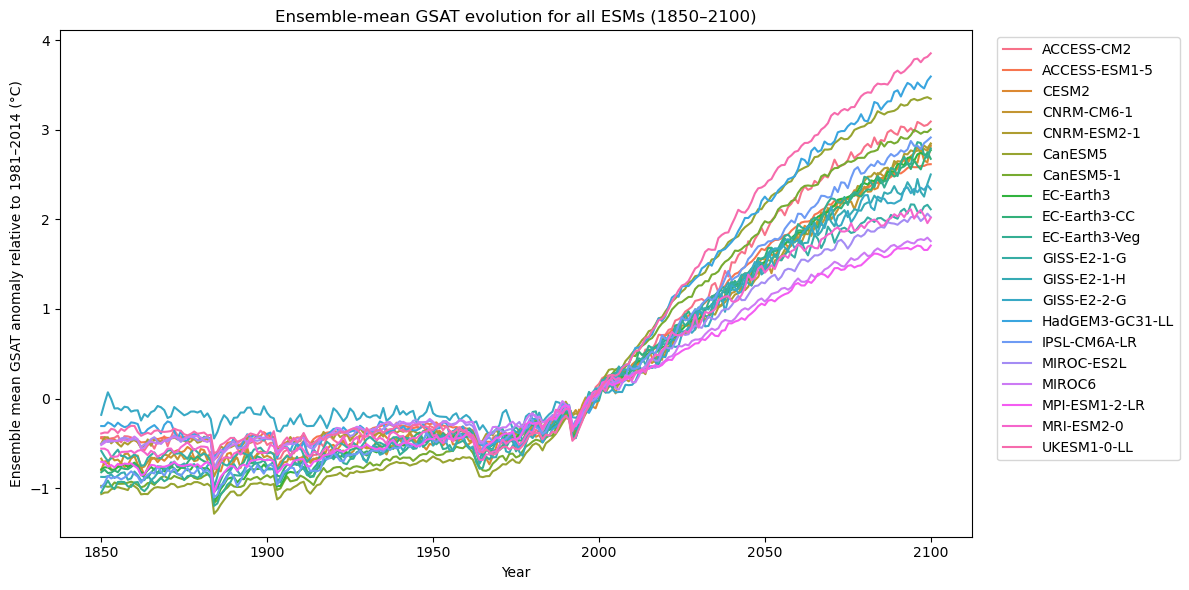

In [124]:
#compute the mean for all ESMs
ensemble_mean=total_df.groupby(["Model","Year"],as_index=False)["Anomaly"].mean()

#plot the results
plt.figure(figsize=(12, 6))
sns.lineplot(data=ensemble_mean, x="Year",y="Anomaly",hue="Model")
plt.xlabel("Year")
plt.ylabel("Ensemble mean GSAT anomaly relative to 1981–2014 baseline in °C")
plt.title("Ensemble-mean GSAT evolution for all ESMs (1850–2100)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


__From now on, we only work with the ensemble mean time series as computed in 2.e).__

__2.f) Compute the CMIP6 multi-model mean warming for 2071-2100, as projected from the entire CMIP6 ensemble.__

In [133]:
#TODO: Your code here
sel_period_warming=ensemble_mean[ensemble_mean["Year"].between(2071,2100).copy()]
warming_per_model=sel_period_warming.groupby(["Model"])["Anomaly"].mean()
cmip6_mean=warming_per_model.mean()
print("CMI6 multi-model mean warming for 2071-2100 as projected from the entire CMIP6 ensemble is:", cmip6_mean )

CMI6 multi-model mean warming for 2071-2100 as projected from the entire CMIP6 ensemble is: 2.451312263261941


__2.g) Calculate the linear trend in GSAT for the historical period 1981-2014 for each ESM. For each ESM calculate also the GSAT at the end-of-century, which for this exercise we define as 2071-2100. Plot these in a scatterplot of historical warming (horizontal axis) versus future warming (vertical axis), where each dot represents one ESM.__

Hint: you can use pd.DataFrame.query() to select parts of a dataframe based on conditions for the values in certain columns. 

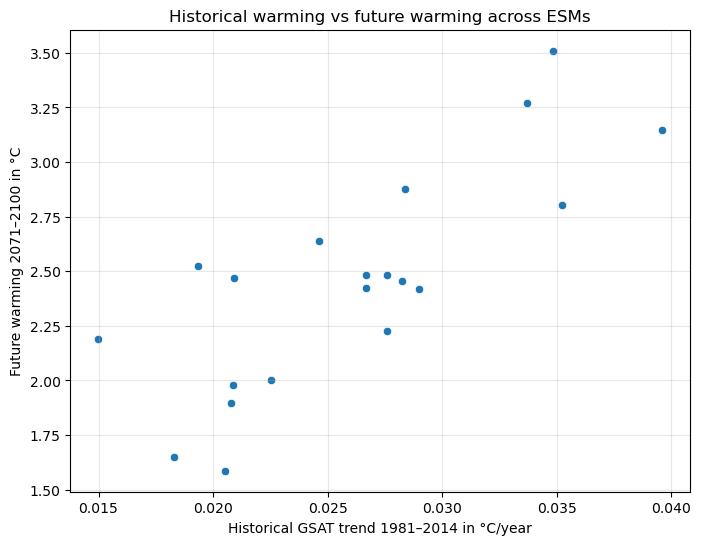

In [158]:
historical_data=ensemble_mean[ensemble_mean["Year"].between(1981,2014)].copy()

#linear regression per model
l_trend_models=[] #res will be stored here

for model, df_model in historical_data.groupby("Model"): #extract the model and corresponding values per year 
    reg=LinearRegression()
    reg.fit(df_model[["Year"]],df_model["Anomaly"])
    slope=reg.coef_[0]
    l_trend_models.append({"Model":model,"historical_trend_per_year":slope}) # store dicts with the results

#convert to pd dataframe
historical_trend=pd.DataFrame(l_trend_models)
historical_trend.head()

#compute end-of-century warming for 2071-2100
future_warming=ensemble_mean[ensemble_mean["Year"].between(2071,2100).copy()].groupby("Model", as_index=False)["Anomaly"].mean().rename(columns={"Anomaly":"future warming"})
future_warming.head()

#combine quantities for a scatter plot
df_scatter=historical_trend.merge(future_warming, on="Model", how="inner")
df_scatter.head()

#plot:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_scatter,x="historical_trend_per_year",y="future warming")
plt.xlabel("Historical GSAT trend 1981–2014 in °C/year")
plt.ylabel("Future warming 2071–2100 in °C")
plt.title("Historical warming vs future warming across ESMs")
plt.grid(True, alpha=0.3)
plt.show()

__2.h) Add a line of best fit (linear regression line through the point cloud) to your plot and compute the Pearson correlation between the historical trends and future warming.__

Hint: You can use sns.regplot() for directly plotting the best linear fit through a point cloud without having to calculate a linear regression. 

Pearson correlation r=0.7910845733746121
p-value p_val=3.278102614972262e-05


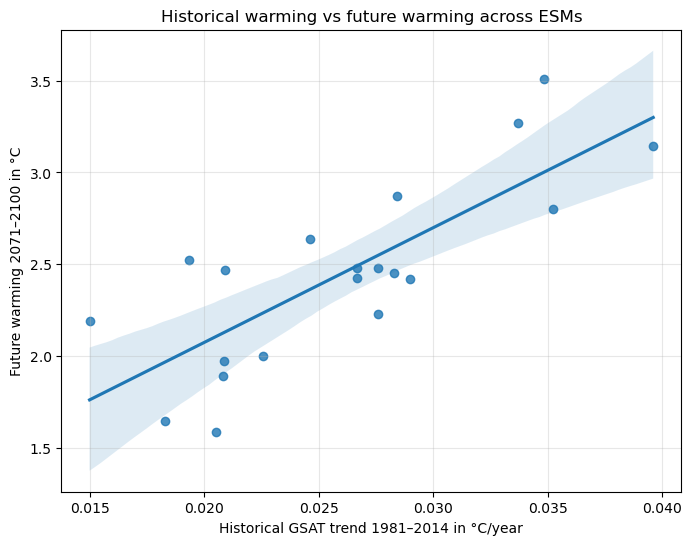

In [162]:
r,p_val=pearsonr(df_scatter["historical_trend_per_year"],df_scatter["future warming"])
print(f"Pearson correlation r={r}")
print(f"p-value p_val={p_val}")

#plotting:
plt.figure(figsize=(8,6))
sns.regplot(data=df_scatter,x="historical_trend_per_year",y="future warming")
plt.xlabel("Historical GSAT trend 1981–2014 in °C/year")
plt.ylabel("Future warming 2071–2100 in °C")
plt.title("Historical warming vs future warming across ESMs")
plt.grid(True, alpha=0.3)



__2.i) What do you observe? What is a possible reason for this relationship?__

### 3. Emergent constraint using observational data
We now want to compare observed historical warming to modelled historical warming in order to create an emergent constraint for end-of-century warming. Here we provide you with a reanalysis dataset, ERA5. The dataset contains annual reanalysis GSAT data from 1940 to 2024. 


__Citation for the dataset:__

ERA5 data can be accessed via https://doi.org/10.24381/cds.f17050d7. 

- Hersbach, H., Bell, B., Berrisford, P., Hirahara, S., Horanyi, A., Munoz-Sabater, J., . . . Thepaut, J.-N. (2020). The ERA5 global reanalysis. Quarterly Journal
of the Royal Meteorological Society, 146 (730), 1999–2049. Retrieved 2024-12-16, from https://onlinelibrary.wiley.com/doi/abs/10.1002/qj.3803 ( eprint: https://onlinelibrary.wiley.com/doi/pdf/10.1002/qj.3803) doi:10.1002/qj.3803

__3.a) Load the observational dataset and inspect it (code below). Plot the observational data together with the CMIP6 models in a sensible way.__



,GSAT_era5,Year
0,286.846039,1940
1,286.891022,1941
2,286.799469,1942
3,286.810059,1943
4,286.995087,1944


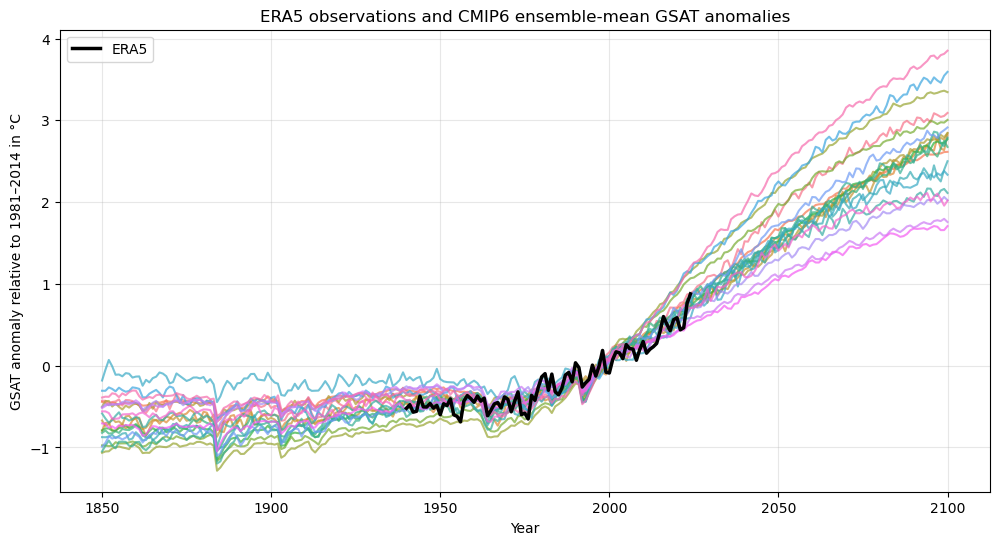

In [166]:
# Load dataframe with ERA5 data
with open(f'{datapath}era5_GSAT.pkl', 'rb') as file: 
    df_era5 = pickle.load(file)

display(df_era5.head())

#just as before we will compute the baseline from 1981-2014

era5_reference=df_era5[df_era5["Year"].between(1981,2014)]["GSAT_era5"].mean()
df_era5["Anomaly"]=df_era5["GSAT_era5"]-era5_reference

#plot ERA5 observations and CMIP6 ensemble mean GSAT anomalies
plt.figure(figsize=(12, 6))
sns.lineplot(data=ensemble_mean,x="Year",y="Anomaly",hue="Model",alpha=0.7,legend=False)
plt.plot(df_era5["Year"],df_era5["Anomaly"],color="black",linewidth=2.5,label="ERA5")
plt.xlabel("Year")
plt.ylabel("GSAT anomaly relative to 1981–2014 in °C")
plt.title("ERA5 observations and CMIP6 ensemble-mean GSAT anomalies")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

__3.b) Just by looking at the plot from 3.a), are there any models you would trust more or less than others, and why?__

__3.c) Plot the observations a vertical line in your scatter plot from 2.a).__


Observed historical trend using ERA5: 0.0165 in °C/year


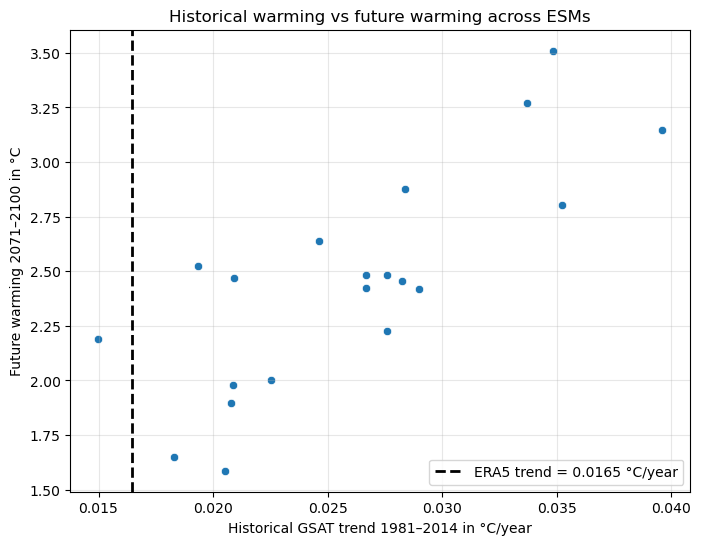

In [181]:
era5_hist=df_era5[df_era5["Year"].between(1981,2014)].copy()

#fit linear trend using LinearRegression
reg=LinearRegression()
reg.fit(era5_hist[["Year"]],era5_hist["Anomaly"])
coeff=reg.coef_[0]

print(f"Observed historical trend using ERA5: {coeff:.4f} in °C/year")

#same plot as seen in 2.g
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_scatter,x="historical_trend_per_year",y="future warming")
# add trend as a vertical line 
plt.axvline(x=coeff,color="black",linestyle="--",linewidth=2,label=f"ERA5 trend = {coeff:.4f} °C/year")
plt.xlabel("Historical GSAT trend 1981–2014 in °C/year")
plt.ylabel("Future warming 2071–2100 in °C")
plt.title("Historical warming vs future warming across ESMs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


__3.d) Use the relationship between historical and future warming to provide a point estimate of a "likely" future warming based on the concept of an emergent constraint.__

In [180]:
#estimate slope and intercept using LinearRegression
X=df_scatter[["historical_trend_per_year"]]
y=df_scatter["future warming"]
new_reg=LinearRegression()
new_reg.fit(X,y)
new_slope=new_reg.coef_[0]
intercept=new_reg.intercept_

print(f"Emergent relationship: future warming= {intercept:.3f}+{new_slope:.3f} * historical trend")

likely_warming=new_reg.predict(pd.DataFrame({"historical_trend_per_year":[coeff]}))[0]

print(f"Observed ERA5 trend: {coeff: .4f} in °C/year")
print(f"Point estimate of a likely future warming: {likely_warming: .3f} in °C")



Emergent relationship: future warming= 0.827+62.424 * historical trend
Observed ERA5 trend:  0.0165 in °C/year
Point estimate of a likely future warming:  1.855 in °C


__3.e) Compare your estimate of end-of-century warming based on the unconstrained multi-model mean (2.c) and the constrained estimate from 3.d).__
    
- (i) Which estimate would you trust more and why? (max. 2 sentences)
- (ii) What factors could bias the constrained estimate in 3.d)? (max. 2 sentences)

__3.f) Repeat the analysis in Section 2 and 3 but this time calculating the historical warming trend in models and observations for the last 35 years, so 1990-2024:__
- (i) Reproduce the scatterplot from 3.c) and compute the Pearson correlation between historical (1990-2024) and future warming as in 2.d).
- (ii) Produce a new point estimate of future warming like in 3.d).

   __How have the results changed? Does your trust in the new point estimate change? Answer in max. 3 sentences.__ 


Pearson correlation r=0.889
p-value=1.674e-07
Observed ERA5 trend from 1990-2024: 0.0241 in °C/year


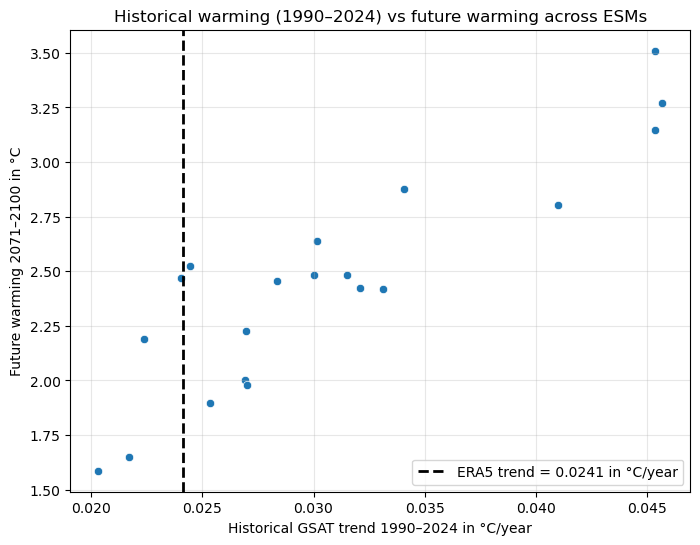

In [198]:
#(i)

#do the same for the 35year period from 1990-2024
historical_35_y=ensemble_mean[ensemble_mean["Year"].between(1990,2024)].copy()
l_trends_35_y=[]

for model, df_model in historical_35_y.groupby("Model"):
    reg_35y=LinearRegression()
    reg_35y.fit(df_model[["Year"]], df_model["Anomaly"])
    l_trends_35_y.append({"Model":model,"historical_trend_35y":reg_35y.coef_[0]})

trend_list=pd.DataFrame(l_trends_35_y)

future_warming_35y=(ensemble_mean[ensemble_mean["Year"].between(2071, 2100)].groupby("Model", as_index=False)["Anomaly"].mean().rename(columns={"Anomaly": "future warming"}))
df_scatter_35y=trend_list.merge(future_warming_35y,on="Model",how="inner")

#compute the correclation coefficient
r_35_y,p_35_y=pearsonr(df_scatter_35y["historical_trend_35y"],df_scatter_35y["future warming"])
print(f"Pearson correlation r={r_35_y:.3f}")
print(f"p-value={p_35_y:.3e}")

#compute trend for ERA5
era_5_35y=df_era5[df_era5["Year"].between(1990, 2024)].copy()
reg_era_35=LinearRegression()
reg_era_35.fit(era_5_35y[["Year"]], era_5_35y["Anomaly"])
slope_era_35=reg_era_35.coef_[0]
print(f"Observed ERA5 trend from 1990-2024: {slope_era_35:.4f} in °C/year")

#plotting
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_scatter_35y,x="historical_trend_35y",y="future warming")
plt.axvline(x=slope_era_35,color="black",linestyle="--",linewidth=2,label=f"ERA5 trend = {slope_era_35:.4f} in °C/year")
plt.xlabel("Historical GSAT trend 1990–2024 in °C/year")
plt.ylabel("Future warming 2071–2100 in °C")
plt.title("Historical warming (1990–2024) vs future warming across ESMs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [200]:
# (ii) emergent-constraint point estimate making use of 1990-2024 data
reg_ec=LinearRegression()
reg_ec.fit(df_scatter_35y[["historical_trend_35y"]], df_scatter_35y["future warming"])
ec_slope=reg_ec.coef_[0]
ec_intercept=reg_ec.intercept_

likely_warming=reg_ec.predict(pd.DataFrame({"historical_trend_35y":[slope_era_35]}))[0]
print(f"Emergent relationship: future warming = {ec_intercept:.3f}+{ec_slope:.3f}* historical trend")
print(f'likely future warming = {likely_warming:.3f} °C')


Emergent relationship: future warming = 0.707+56.652* historical trend
likely future warming = 2.075 °C


__3.g) Can you think of a reason why the point estimate of future warming based on the emergent constraint changed when changing the analysis period from 1981-2014 in 3.d) to 1990-2024 in 3.f)?__

__3.h) If you had to provide a "likely" range instead of just a point estimate of end-of-century warming, what kind of uncertainties would you need to take into account?__

## IMPROVEMENTS

In [201]:
# ============================================================
# 0. Setup
# ============================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# Make sure ERA5 anomalies exist
if "Anomaly" not in df_era5.columns:
    era5_ref = df_era5[df_era5["Year"].between(1981, 2014)]["GSAT_era5"].mean()
    df_era5["Anomaly"] = df_era5["GSAT_era5"] - era5_ref

# Make sure model ensemble means exist
# one anomaly time series per model
if "ensemble_mean" not in globals():
    ensemble_mean = (
        total_df.groupby(["Model", "Year"], as_index=False)["Anomaly"]
        .mean()
    )

def fit_linear_trend(years, values):
    """Return linear trend in units of anomaly per year."""
    reg = LinearRegression()
    reg.fit(np.asarray(years).reshape(-1, 1), np.asarray(values))
    return reg.coef_[0]

def get_obs_series(df_era5, start, end):
    """Observed anomaly series indexed by Year."""
    obs = df_era5[df_era5["Year"].between(start, end)].copy()
    return obs.set_index("Year")["Anomaly"].sort_index()

def get_model_matrix(ensemble_mean, start, end):
    """
    Wide matrix:
    rows = Year
    columns = Model
    values = ensemble-mean anomaly
    """
    tmp = ensemble_mean[ensemble_mean["Year"].between(start, end)].copy()
    mat = tmp.pivot(index="Year", columns="Model", values="Anomaly").sort_index()
    return mat

def get_future_warming_per_model(ensemble_mean, start=2071, end=2100):
    """Mean future warming per model over target period."""
    return (
        ensemble_mean[ensemble_mean["Year"].between(start, end)]
        .groupby("Model")["Anomaly"]
        .mean()
        .sort_index()
    )

def normalize_weights(w):
    """Normalize nonnegative weights to sum to 1."""
    w = pd.Series(w, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    w = w.clip(lower=0.0)
    s = w.sum()
    if s == 0:
        return pd.Series(np.ones(len(w)) / len(w), index=w.index)
    return w / s

def compute_independence_weights(model_train):
    """
    Very simple independence weighting:
    - compute pairwise distances between model historical trajectories
    - models very similar to many others get downweighted
    """
    models = model_train.columns
    D = pd.DataFrame(index=models, columns=models, dtype=float)

    for i in models:
        for j in models:
            D.loc[i, j] = np.sqrt(np.mean((model_train[i] - model_train[j]) ** 2))

    offdiag = D.values[np.triu_indices_from(D.values, k=1)]
    offdiag = offdiag[offdiag > 0]

    # distance scale
    d0 = np.median(offdiag) if len(offdiag) > 0 else 1.0

    # similarity and redundancy
    similarity = np.exp(-(D / d0) ** 2)
    redundancy = similarity.sum(axis=1)   # includes self-similarity = 1

    w_ind = normalize_weights(1.0 / redundancy)
    return w_ind, D

def compute_weights(obs_train, model_train):
    """
    Build several weighting schemes from a training period.

    Schemes:
    - equal
    - rmse: better historical fit to observed trajectory => larger weight
    - trend: historical trend closer to observed trend => larger weight
    - perf: combines rmse + trend agreement
    - independence: downweights clusters of very similar models
    - perf_x_independence: combined performance + independence
    """
    common_years = obs_train.index.intersection(model_train.index)
    obs = obs_train.loc[common_years]
    X = model_train.loc[common_years]

    # observed historical trend
    obs_trend = fit_linear_trend(obs.index.values, obs.values)

    # model metrics
    rmse = np.sqrt(((X.sub(obs, axis=0)) ** 2).mean(axis=0))

    model_trends = pd.Series({
        m: fit_linear_trend(X.index.values, X[m].values)
        for m in X.columns
    })

    trend_err = model_trends - obs_trend

    # scales for Gaussian-style weights
    rmse_scale = np.median(rmse[rmse > 0]) if np.any(rmse > 0) else 1.0
    trend_scale = np.median(np.abs(trend_err[trend_err != 0])) if np.any(trend_err != 0) else 1.0

    # baseline
    w_equal = normalize_weights(pd.Series(1.0, index=X.columns))

    # historical trajectory skill
    w_rmse = normalize_weights(np.exp(-0.5 * (rmse / rmse_scale) ** 2))

    # emergent-constraint-like: historical trend agreement
    w_trend = normalize_weights(np.exp(-0.5 * (trend_err / trend_scale) ** 2))

    # combined performance
    perf_score = np.exp(
        -0.5 * (rmse / rmse_scale) ** 2
        -0.5 * (trend_err / trend_scale) ** 2
    )
    w_perf = normalize_weights(perf_score)

    # independence
    w_ind, D = compute_independence_weights(X)

    # performance + independence
    w_perf_ind = normalize_weights(perf_score * w_ind)

    diagnostics = pd.DataFrame({
        "rmse_hist": rmse,
        "trend_hist": model_trends,
        "trend_error": trend_err,
        "w_equal": w_equal,
        "w_rmse": w_rmse,
        "w_trend": w_trend,
        "w_perf": w_perf,
        "w_independence": w_ind,
        "w_perf_x_ind": w_perf_ind,
    }).sort_values("w_perf_x_ind", ascending=False)

    weights = {
        "equal": w_equal,
        "rmse": w_rmse,
        "trend": w_trend,
        "perf": w_perf,
        "independence": w_ind,
        "perf_x_independence": w_perf_ind,
    }

    return weights, diagnostics, D, obs_trend

def weighted_series(model_matrix, weights):
    """Weighted model-mean trajectory."""
    w = weights.reindex(model_matrix.columns)
    return model_matrix.mul(w, axis=1).sum(axis=1)

def weighted_future_estimate(future_per_model, weights):
    """Weighted point estimate of end-of-century warming."""
    aligned = future_per_model.reindex(weights.index)
    return float((aligned * weights).sum())

In [202]:
# ============================================================
# 1. Choose periods
# ============================================================

train_start, train_end = 1940, 1989
test_start, test_end = 1990, 2024
future_start, future_end = 2071, 2100

obs_train = get_obs_series(df_era5, train_start, train_end)
obs_test = get_obs_series(df_era5, test_start, test_end)

model_train = get_model_matrix(ensemble_mean, train_start, train_end)
model_test = get_model_matrix(ensemble_mean, test_start, test_end)

future_per_model = get_future_warming_per_model(
    ensemble_mean,
    start=future_start,
    end=future_end
)

weights_dict, diagnostics, D, obs_trend_train = compute_weights(obs_train, model_train)

display(diagnostics.head(10))

,rmse_hist,trend_hist,trend_error,w_equal,w_rmse,w_trend,w_perf,w_independence,w_perf_x_ind
CanESM5-1,0.197960,0.004678,-0.001685,0.05,0.032852,0.080562,0.049388,0.092617,0.109742
EC-Earth3-Veg,0.131249,0.005070,-0.001292,0.05,0.058016,0.085372,0.092428,0.045682,0.101299
CanESM5,0.262094,0.005136,-0.001227,0.05,0.015302,0.086074,0.024578,0.160300,0.094522
MPI-ESM1-2-LR,0.102806,0.005918,-0.000445,0.05,0.068932,0.091841,0.118139,0.032207,0.091284
IPSL-CM6A-LR,0.104879,0.005158,-0.001205,0.05,0.068167,0.086306,0.109789,0.032703,0.086140
EC-Earth3,0.111020,0.004515,-0.001848,0.05,0.065867,0.078297,0.096239,0.030825,0.071172
CESM2,0.135910,0.003924,-0.002439,0.05,0.056175,0.069046,0.072381,0.039269,0.068191
CNRM-CM6-1,0.111086,0.004193,-0.002170,0.05,0.065842,0.073424,0.090216,0.030964,0.067019
GISS-E2-1-G,0.130723,0.004191,-0.002171,0.05,0.058224,0.073401,0.079752,0.033782,0.064637
GISS-E2-1-H,0.141998,0.002793,-0.003570,0.05,0.053767,0.049290,0.049456,0.044946,0.053329


In [203]:
# ============================================================
# 2. Compute weighted end-of-century point estimates
# ============================================================

future_estimates = []

for scheme, w in weights_dict.items():
    est = weighted_future_estimate(future_per_model, w)
    future_estimates.append({
        "scheme": scheme,
        "weighted_future_warming_2071_2100": est
    })

future_estimates_df = pd.DataFrame(future_estimates).sort_values(
    "weighted_future_warming_2071_2100"
)

display(future_estimates_df)

,scheme,weighted_future_warming_2071_2100
3,perf,2.324261
2,trend,2.388156
5,perf_x_independence,2.415390
1,rmse,2.423201
0,equal,2.451312
4,independence,2.524397


In [204]:
# ============================================================
# 3. Benchmark 1: held-out hindcast against observations
# ============================================================

def evaluate_against_obs(weights_dict, model_test, obs_test):
    common_years = obs_test.index.intersection(model_test.index)
    obs = obs_test.loc[common_years]
    X = model_test.loc[common_years]

    obs_trend = fit_linear_trend(obs.index.values, obs.values)

    rows = []

    for scheme, w in weights_dict.items():
        pred = weighted_series(X, w)

        rmse = np.sqrt(np.mean((pred - obs) ** 2))
        mae = np.mean(np.abs(pred - obs))
        bias = np.mean(pred - obs)
        corr = pred.corr(obs)

        pred_trend = fit_linear_trend(pred.index.values, pred.values)
        trend_error = pred_trend - obs_trend

        rows.append({
            "scheme": scheme,
            "rmse_test_traj": rmse,
            "mae_test_traj": mae,
            "bias_test_traj": bias,
            "corr_test_traj": corr,
            "trend_error_test": trend_error,
            "abs_trend_error_test": abs(trend_error),
        })

    return pd.DataFrame(rows).sort_values("rmse_test_traj")

hindcast_scores = evaluate_against_obs(weights_dict, model_test, obs_test)
display(hindcast_scores)

,scheme,rmse_test_traj,mae_test_traj,bias_test_traj,corr_test_traj,trend_error_test,abs_trend_error_test
3,perf,0.114489,0.096376,0.024080,0.923708,0.004218,0.004218
1,rmse,0.124162,0.103774,0.035295,0.924275,0.005911,0.005911
2,trend,0.124498,0.104545,0.037034,0.923465,0.005755,0.005755
5,perf_x_independence,0.129216,0.108730,0.042332,0.923319,0.006359,0.006359
0,equal,0.129667,0.108439,0.040766,0.923929,0.006643,0.006643
4,independence,0.144732,0.121750,0.055191,0.922526,0.008302,0.008302


In [205]:
# ============================================================
# 4. Benchmark 2: perfect-model test
# ============================================================

def perfect_model_test(
    ensemble_mean,
    train_start=1940,
    train_end=1989,
    future_start=2071,
    future_end=2100
):
    train_matrix = get_model_matrix(ensemble_mean, train_start, train_end)
    future_target = get_future_warming_per_model(
        ensemble_mean,
        start=future_start,
        end=future_end
    )

    models = list(train_matrix.columns)
    rows = []

    for truth_model in models:
        # pseudo-observation = historical trajectory of this model
        pseudo_obs = train_matrix[truth_model]

        # candidate models = all others
        candidate_train = train_matrix.drop(columns=truth_model)
        candidate_future = future_target.drop(index=truth_model)

        weights_dict_pm, _, _, _ = compute_weights(pseudo_obs, candidate_train)

        true_future = future_target.loc[truth_model]

        for scheme, w in weights_dict_pm.items():
            pred_future = weighted_future_estimate(candidate_future, w)

            rows.append({
                "truth_model": truth_model,
                "scheme": scheme,
                "true_future": true_future,
                "pred_future": pred_future,
                "error": pred_future - true_future,
                "abs_error": abs(pred_future - true_future),
            })

    return pd.DataFrame(rows)

pm_results = perfect_model_test(
    ensemble_mean,
    train_start=train_start,
    train_end=train_end,
    future_start=future_start,
    future_end=future_end
)

pm_summary = (
    pm_results.groupby("scheme")[["abs_error", "error"]]
    .agg(mean_abs_error=("abs_error", "mean"),
         median_abs_error=("abs_error", "median"),
         mean_signed_error=("error", "mean"))
    .sort_values("mean_abs_error")
)

display(pm_summary)

,mean_abs_error,median_abs_error,mean_signed_error
scheme,,,
perf_x_independence,0.367256,0.325029,-3.723838e-02
rmse,0.383106,0.292967,-1.899639e-02
equal,0.388393,0.321348,2.664535e-16
trend,0.398243,0.349885,-4.010493e-02
perf,0.399233,0.373337,-6.851117e-02
independence,0.400293,0.340220,7.136139e-02


In [206]:
# ============================================================
# 5. Combine benchmark tables
# ============================================================

benchmark_table = hindcast_scores.merge(
    pm_summary.reset_index(),
    on="scheme",
    how="left"
)

display(benchmark_table.sort_values(["rmse_test_traj", "mean_abs_error"]))

,scheme,rmse_test_traj,mae_test_traj,bias_test_traj,corr_test_traj,trend_error_test,abs_trend_error_test,mean_abs_error,median_abs_error,mean_signed_error
0,perf,0.114489,0.096376,0.024080,0.923708,0.004218,0.004218,0.399233,0.373337,-6.851117e-02
1,rmse,0.124162,0.103774,0.035295,0.924275,0.005911,0.005911,0.383106,0.292967,-1.899639e-02
2,trend,0.124498,0.104545,0.037034,0.923465,0.005755,0.005755,0.398243,0.349885,-4.010493e-02
3,perf_x_independence,0.129216,0.108730,0.042332,0.923319,0.006359,0.006359,0.367256,0.325029,-3.723838e-02
4,equal,0.129667,0.108439,0.040766,0.923929,0.006643,0.006643,0.388393,0.321348,2.664535e-16
5,independence,0.144732,0.121750,0.055191,0.922526,0.008302,0.008302,0.400293,0.340220,7.136139e-02


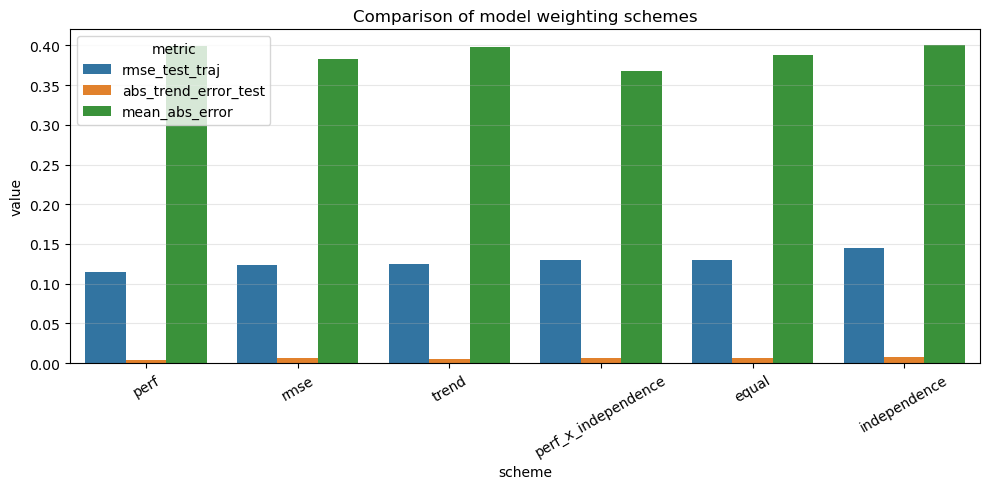

In [207]:
# ============================================================
# 6. Visual comparison of schemes
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plot_df = benchmark_table.melt(
    id_vars="scheme",
    value_vars=["rmse_test_traj", "abs_trend_error_test", "mean_abs_error"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="scheme", y="value", hue="metric")
plt.xticks(rotation=30)
plt.title("Comparison of model weighting schemes")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [208]:
# ============================================================
# 1. Fit weights using all available observations up to 2024
# ============================================================

calib_start, calib_end = 1940, 2024
future_plot_start, future_plot_end = 2025, 2100
future_mean_start, future_mean_end = 2071, 2100

obs_calib = get_obs_series(df_era5, calib_start, calib_end)
model_calib = get_model_matrix(ensemble_mean, calib_start, calib_end)

weights_future, diagnostics_future, D_future, obs_trend_calib = compute_weights(
    obs_calib,
    model_calib
)

display(diagnostics_future.sort_values("w_perf_x_ind", ascending=False).head(10))

,rmse_hist,trend_hist,trend_error,w_equal,w_rmse,w_trend,w_perf,w_independence,w_perf_x_ind
CESM2,0.136533,0.014333,0.000421,0.05,0.057427,0.090507,0.089508,0.038412,0.095455
MRI-ESM2-0,0.119414,0.013537,-0.000375,0.05,0.064355,0.091526,0.101434,0.033102,0.093219
GISS-E2-1-G,0.122548,0.013372,-0.000540,0.05,0.063098,0.087377,0.094945,0.033726,0.088901
CNRM-CM6-1,0.111576,0.013166,-0.000746,0.05,0.067455,0.080566,0.093590,0.034114,0.088640
IPSL-CM6A-LR,0.114768,0.014584,0.000672,0.05,0.066201,0.083204,0.094857,0.032628,0.085926
EC-Earth3,0.122826,0.014283,0.000371,0.05,0.062987,0.091595,0.099353,0.031031,0.085596
ACCESS-CM2,0.156931,0.013858,-0.000053,0.05,0.049153,0.095473,0.080814,0.036657,0.082247
GISS-E2-1-H,0.135863,0.015008,0.001096,0.05,0.057700,0.066116,0.065697,0.042350,0.077244
MPI-ESM1-2-LR,0.114138,0.012608,-0.001303,0.05,0.066449,0.056733,0.064921,0.039436,0.071080
EC-Earth3-CC,0.140457,0.014656,0.000744,0.05,0.055828,0.080634,0.077523,0.032533,0.070021


In [209]:
# ============================================================
# 2. Build weighted trajectories for the whole model period
# ============================================================

full_model_matrix = get_model_matrix(ensemble_mean, 1850, 2100)

weighted_trajectories = pd.DataFrame(index=full_model_matrix.index)

for scheme, w in weights_future.items():
    weighted_trajectories[scheme] = weighted_series(full_model_matrix, w)

display(weighted_trajectories.head())

,equal,rmse,trend,perf,independence,perf_x_independence
Year,,,,,,
1850,-0.658026,-0.670737,-0.674540,-0.692882,-0.676988,-0.685203
1851,-0.638005,-0.653060,-0.665601,-0.684641,-0.653606,-0.676434
1852,-0.630950,-0.649202,-0.669389,-0.688374,-0.641400,-0.679600
1853,-0.639945,-0.660415,-0.678525,-0.698148,-0.646634,-0.688973
1854,-0.645211,-0.664319,-0.679409,-0.698498,-0.653472,-0.691075


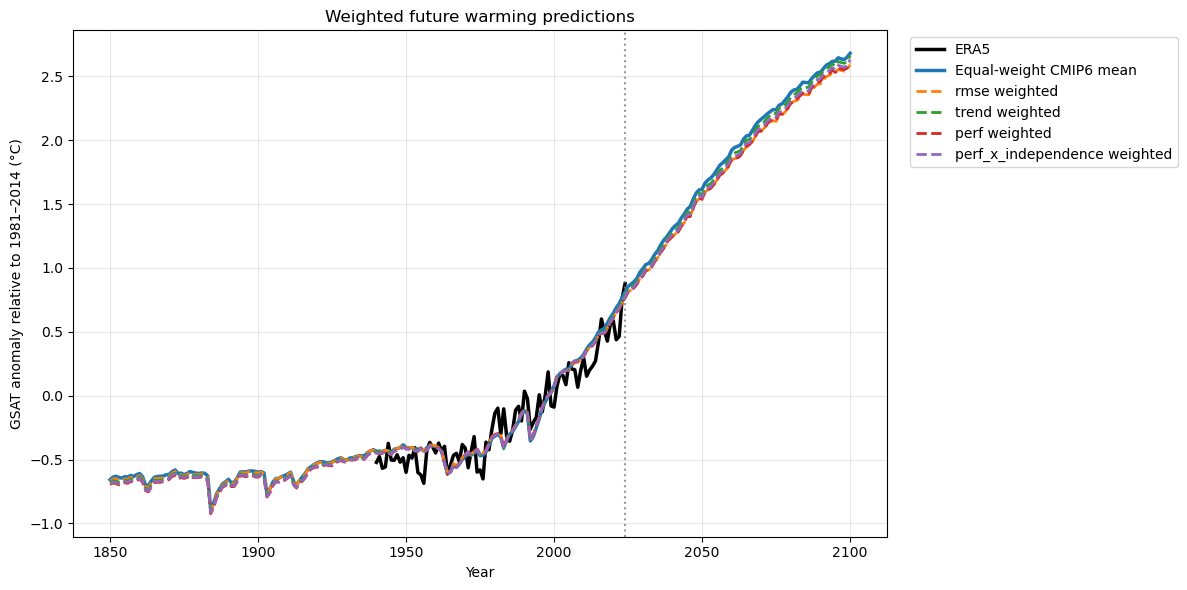

In [210]:
# ============================================================
# 3. Plot future warming trajectories
# ============================================================

plt.figure(figsize=(12, 6))

# historical observations
plt.plot(
    df_era5["Year"],
    df_era5["Anomaly"],
    color="black",
    linewidth=2.5,
    label="ERA5"
)

# baseline equal-weight CMIP6 mean
plt.plot(
    weighted_trajectories.index,
    weighted_trajectories["equal"],
    linewidth=2.5,
    label="Equal-weight CMIP6 mean"
)

# selected weighted schemes
for scheme in ["rmse", "trend", "perf", "perf_x_independence"]:
    plt.plot(
        weighted_trajectories.index,
        weighted_trajectories[scheme],
        linestyle="--",
        linewidth=2,
        label=f"{scheme} weighted"
    )

plt.axvline(2024, color="gray", linestyle=":", alpha=0.8)
plt.xlabel("Year")
plt.ylabel("GSAT anomaly relative to 1981–2014 (°C)")
plt.title("Weighted future warming predictions")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [211]:
# ============================================================
# 4. End-of-century warming estimates
# ============================================================

future_period = weighted_trajectories.loc[
    weighted_trajectories.index.to_series().between(future_mean_start, future_mean_end)
]

future_estimates_plot = (
    future_period.mean(axis=0)
    .rename("warming_2071_2100")
    .reset_index()
    .rename(columns={"index": "scheme"})
    .sort_values("warming_2071_2100")
)

display(future_estimates_plot)

,scheme,warming_2071_2100
1,rmse,2.361364
3,perf,2.372215
5,perf_x_independence,2.392311
2,trend,2.421358
0,equal,2.451312
4,independence,2.571589


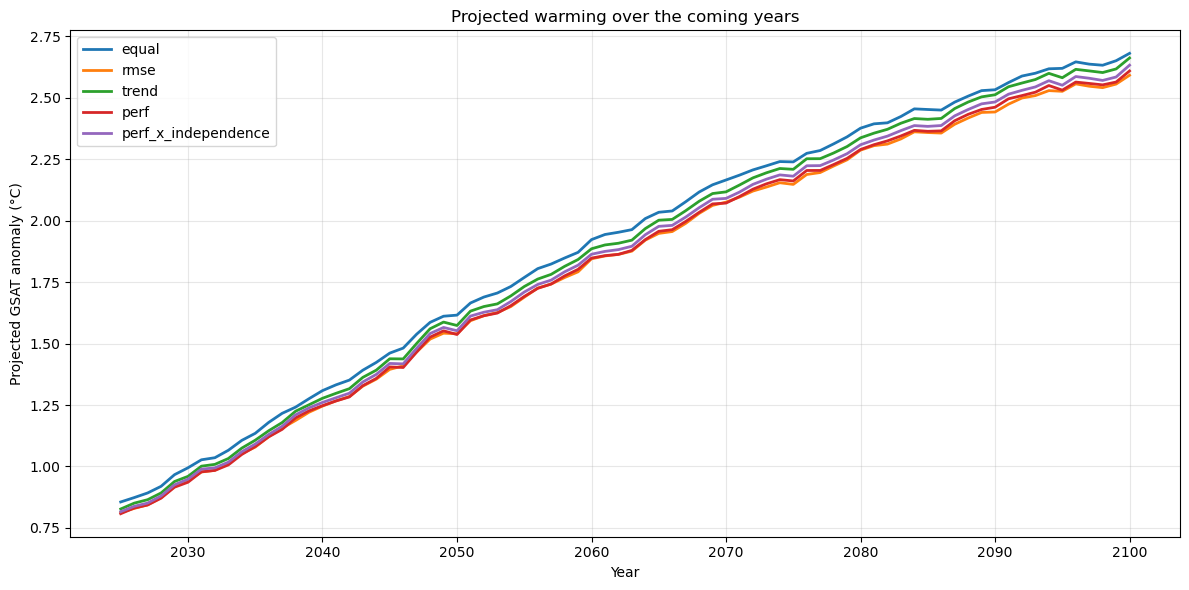

In [212]:
# ============================================================
# 5. Future-only plot
# ============================================================

future_only = weighted_trajectories.loc[
    weighted_trajectories.index.to_series().between(future_plot_start, future_plot_end)
]

plt.figure(figsize=(12, 6))

for scheme in ["equal", "rmse", "trend", "perf", "perf_x_independence"]:
    plt.plot(
        future_only.index,
        future_only[scheme],
        linewidth=2,
        label=scheme
    )

plt.xlabel("Year")
plt.ylabel("Projected GSAT anomaly (°C)")
plt.title("Projected warming over the coming years")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

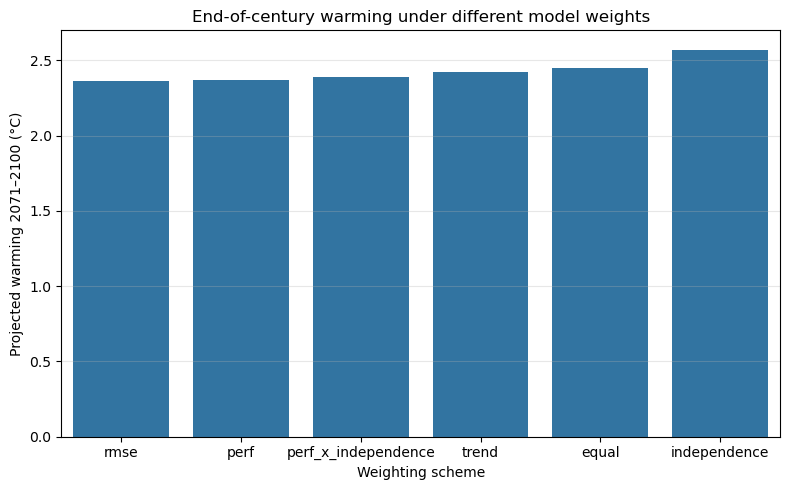

In [213]:
# ============================================================
# 6. Bar plot of end-of-century warming estimates
# ============================================================

plt.figure(figsize=(8, 5))
sns.barplot(
    data=future_estimates_plot,
    x="scheme",
    y="warming_2071_2100"
)
plt.ylabel("Projected warming 2071–2100 (°C)")
plt.xlabel("Weighting scheme")
plt.title("End-of-century warming under different model weights")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [214]:
# recompute point estimates directly from weights_future
future_per_model = get_future_warming_per_model(
    ensemble_mean,
    start=future_mean_start,
    end=future_mean_end
)

future_estimates_corrected = []

for scheme, w in weights_future.items():
    future_estimates_corrected.append({
        "scheme": scheme,
        "warming_2071_2100": weighted_future_estimate(future_per_model, w)
    })

future_estimates_corrected = pd.DataFrame(future_estimates_corrected).sort_values("warming_2071_2100")
display(future_estimates_corrected)

,scheme,warming_2071_2100
1,rmse,2.361364
3,perf,2.372215
5,perf_x_independence,2.392311
2,trend,2.421358
0,equal,2.451312
4,independence,2.571589


In [215]:
# future warming per model
future_per_model = (
    ensemble_mean[ensemble_mean["Year"].between(2071, 2100)]
    .groupby("Model")["Anomaly"]
    .mean()
    .sort_index()
)

def weighted_quantile(values, quantiles, sample_weight=None):
    values = np.asarray(values)
    quantiles = np.asarray(quantiles)
    if sample_weight is None:
        sample_weight = np.ones(len(values))
    sample_weight = np.asarray(sample_weight)

    sorter = np.argsort(values)
    values = values[sorter]
    sample_weight = sample_weight[sorter]

    cum_weights = np.cumsum(sample_weight)
    cum_weights = cum_weights / cum_weights[-1]

    return np.interp(quantiles, cum_weights, values)

# example: performance + independence weights
w = weights_future["perf_x_independence"].reindex(future_per_model.index)

weighted_mean = np.sum(w * future_per_model)
likely_66 = weighted_quantile(future_per_model.values, [0.17, 0.83], w.values)
likely_90 = weighted_quantile(future_per_model.values, [0.05, 0.95], w.values)

print("Weighted mean:", round(weighted_mean, 3), "°C")
print("Likely 66% range:", np.round(likely_66, 3), "°C")
print("90% range:", np.round(likely_90, 3), "°C")

Weighted mean: 2.392 °C
Likely 66% range: [1.978 2.595] °C
90% range: [1.587 3.164] °C


In [216]:
# Use the full-calibration weights, not the older train/test weights
selected_schemes = ["equal", "trend", "perf", "perf_x_independence"]

# Full model matrix: one ensemble-mean anomaly trajectory per model
full_model_matrix = get_model_matrix(ensemble_mean, 1850, 2100)

# Future-only model matrix
future_model_matrix = get_model_matrix(ensemble_mean, 2025, 2100)

# Weighted trajectories for all years
weighted_trajectories = pd.DataFrame(index=full_model_matrix.index)
for scheme in selected_schemes:
    weighted_trajectories[scheme] = weighted_series(full_model_matrix, weights_future[scheme])

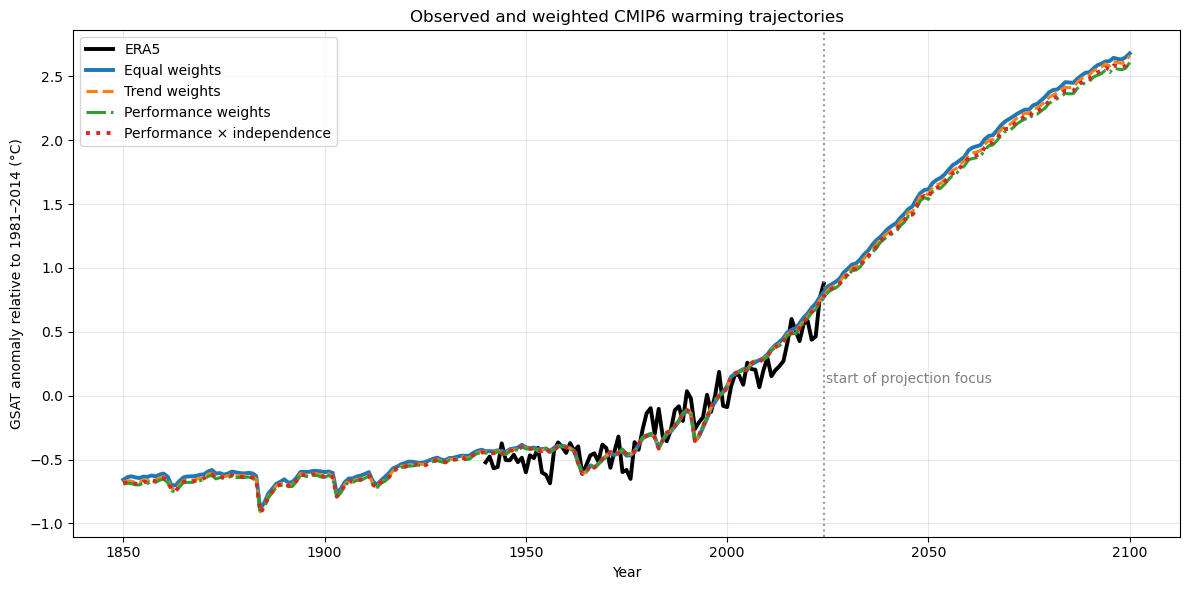

In [217]:
plt.figure(figsize=(12, 6))

# Observations
plt.plot(
    df_era5["Year"],
    df_era5["Anomaly"],
    color="black",
    linewidth=2.8,
    label="ERA5"
)

# Weighted model trajectories
styles = {
    "equal": ("solid", 2.8),
    "trend": ("--", 2.2),
    "perf": ("-.", 2.2),
    "perf_x_independence": (":", 2.8),
}

labels = {
    "equal": "Equal weights",
    "trend": "Trend weights",
    "perf": "Performance weights",
    "perf_x_independence": "Performance × independence"
}

for scheme in selected_schemes:
    ls, lw = styles[scheme]
    plt.plot(
        weighted_trajectories.index,
        weighted_trajectories[scheme],
        linestyle=ls,
        linewidth=lw,
        label=labels[scheme]
    )

plt.axvline(2024, color="gray", linestyle=":", alpha=0.8)
plt.text(2024.5, 0.1, "start of projection focus", color="gray")

plt.xlabel("Year")
plt.ylabel("GSAT anomaly relative to 1981–2014 (°C)")
plt.title("Observed and weighted CMIP6 warming trajectories")
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

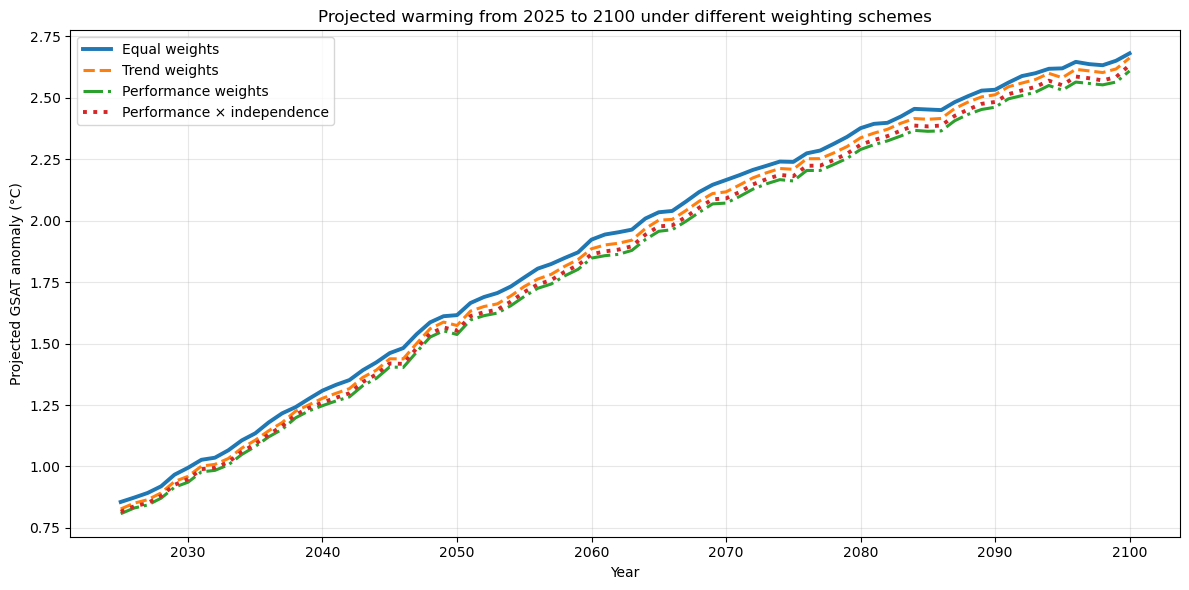

In [218]:
future_only = weighted_trajectories.loc[
    weighted_trajectories.index.to_series().between(2025, 2100)
]

plt.figure(figsize=(12, 6))

for scheme in selected_schemes:
    ls, lw = styles[scheme]
    plt.plot(
        future_only.index,
        future_only[scheme],
        linestyle=ls,
        linewidth=lw,
        label=labels[scheme]
    )

plt.xlabel("Year")
plt.ylabel("Projected GSAT anomaly (°C)")
plt.title("Projected warming from 2025 to 2100 under different weighting schemes")
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

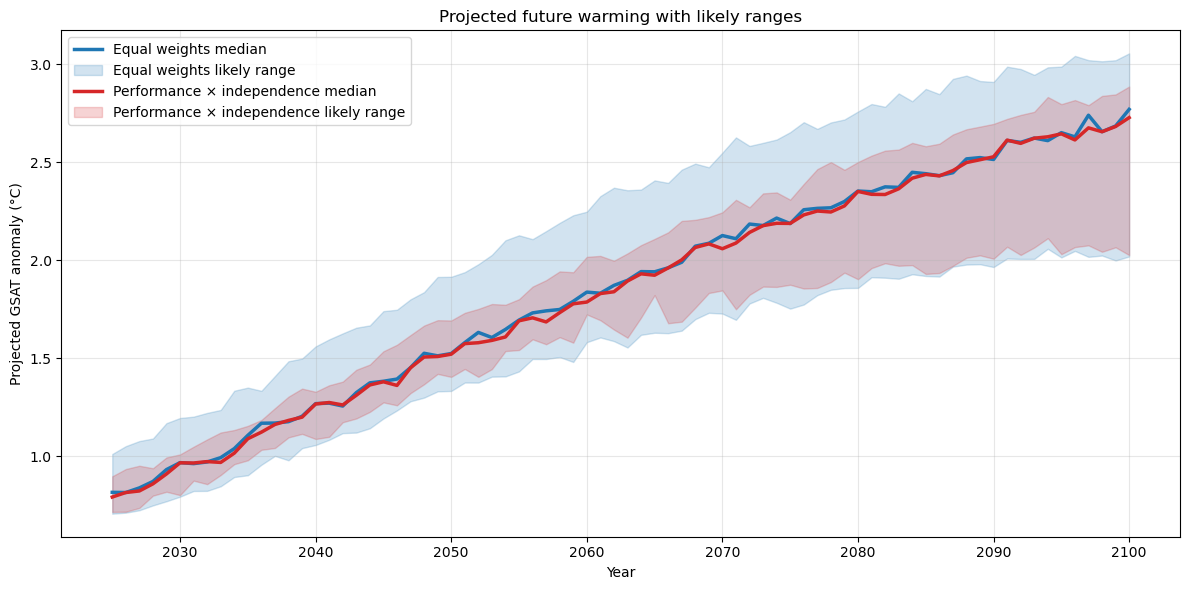

In [219]:
def weighted_quantile(values, quantiles, sample_weight=None):
    values = np.asarray(values)
    quantiles = np.asarray(quantiles)
    if sample_weight is None:
        sample_weight = np.ones(len(values))
    sample_weight = np.asarray(sample_weight)

    sorter = np.argsort(values)
    values = values[sorter]
    sample_weight = sample_weight[sorter]

    cum_weights = np.cumsum(sample_weight)
    cum_weights = cum_weights / cum_weights[-1]

    return np.interp(quantiles, cum_weights, values)

# Build weighted ranges for each year
future_ranges = {}

for scheme in selected_schemes:
    w = weights_future[scheme].reindex(future_model_matrix.columns)

    rows = []
    for year in future_model_matrix.index:
        vals = future_model_matrix.loc[year].values
        q17, q50, q83 = weighted_quantile(vals, [0.17, 0.50, 0.83], w.values)
        rows.append({
            "Year": year,
            "q17": q17,
            "q50": q50,
            "q83": q83
        })

    future_ranges[scheme] = pd.DataFrame(rows).set_index("Year")

# Plot only the two most relevant ranges
plt.figure(figsize=(12, 6))

for scheme, color in zip(["equal", "perf_x_independence"], ["tab:blue", "tab:red"]):
    fr = future_ranges[scheme]
    plt.plot(fr.index, fr["q50"], linewidth=2.5, label=f"{labels[scheme]} median", color=color)
    plt.fill_between(fr.index, fr["q17"], fr["q83"], alpha=0.20, color=color,
                     label=f"{labels[scheme]} likely range")

plt.xlabel("Year")
plt.ylabel("Projected GSAT anomaly (°C)")
plt.title("Projected future warming with likely ranges")
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

,scheme,mean,q17,q50,q83
2,Performance weights,2.372215,1.977506,2.438495,2.566800
3,Performance × independence,2.392311,1.977973,2.439654,2.595109
1,Trend weights,2.421358,1.982218,2.443329,2.625213
0,Equal weights,2.451312,1.927723,2.455399,2.845142


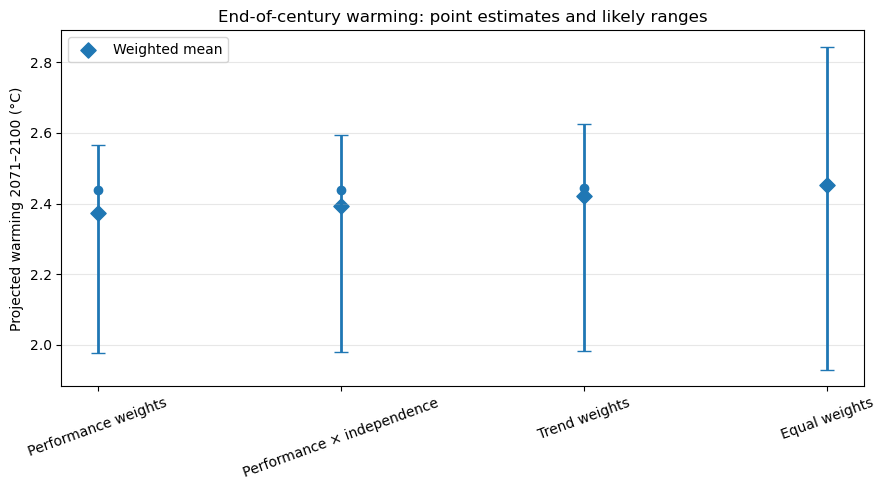

In [220]:
# End-of-century warming distribution per model
future_per_model = get_future_warming_per_model(
    ensemble_mean,
    start=2071,
    end=2100
)

summary_rows = []

for scheme in selected_schemes:
    w = weights_future[scheme].reindex(future_per_model.index)

    mean_val = np.sum(w * future_per_model)
    q17, q50, q83 = weighted_quantile(future_per_model.values, [0.17, 0.50, 0.83], w.values)

    summary_rows.append({
        "scheme": labels[scheme],
        "mean": mean_val,
        "q17": q17,
        "q50": q50,
        "q83": q83
    })

summary_df = pd.DataFrame(summary_rows).sort_values("mean")
display(summary_df)

plt.figure(figsize=(9, 5))

x = np.arange(len(summary_df))
plt.errorbar(
    x,
    summary_df["q50"],
    yerr=[summary_df["q50"] - summary_df["q17"], summary_df["q83"] - summary_df["q50"]],
    fmt="o",
    capsize=5,
    linewidth=2
)

plt.scatter(x, summary_df["mean"], marker="D", s=60, label="Weighted mean")

plt.xticks(x, summary_df["scheme"], rotation=20)
plt.ylabel("Projected warming 2071–2100 (°C)")
plt.title("End-of-century warming: point estimates and likely ranges")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

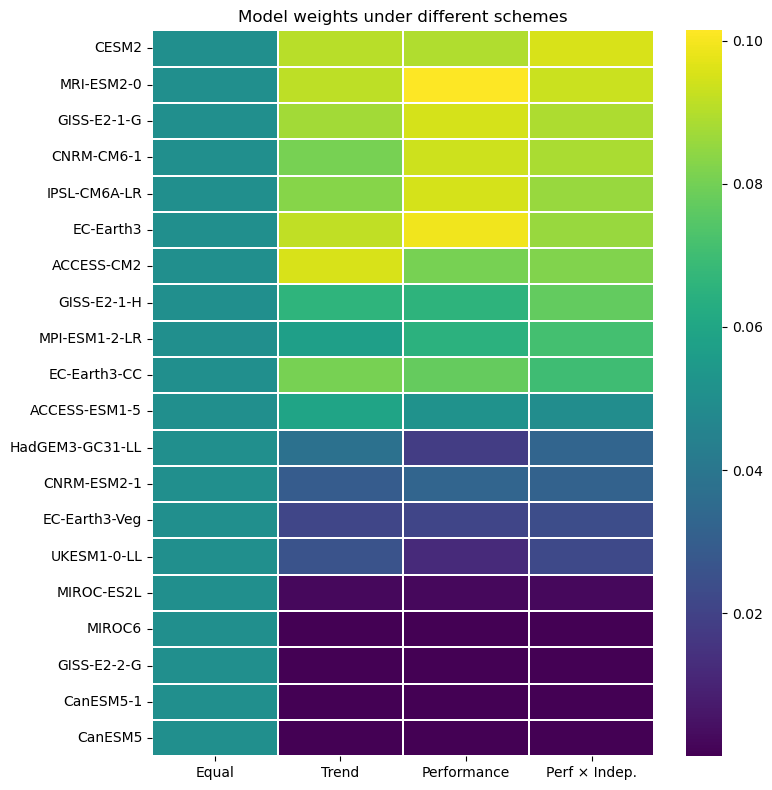

In [221]:
weight_plot_df = diagnostics_future[
    ["w_equal", "w_trend", "w_perf", "w_perf_x_ind"]
].copy()

weight_plot_df = weight_plot_df.rename(columns={
    "w_equal": "Equal",
    "w_trend": "Trend",
    "w_perf": "Performance",
    "w_perf_x_ind": "Perf × Indep."
})

plt.figure(figsize=(8, 8))
sns.heatmap(
    weight_plot_df.sort_values("Perf × Indep.", ascending=False),
    cmap="viridis",
    linewidths=0.2
)
plt.title("Model weights under different schemes")
plt.tight_layout()
plt.show()

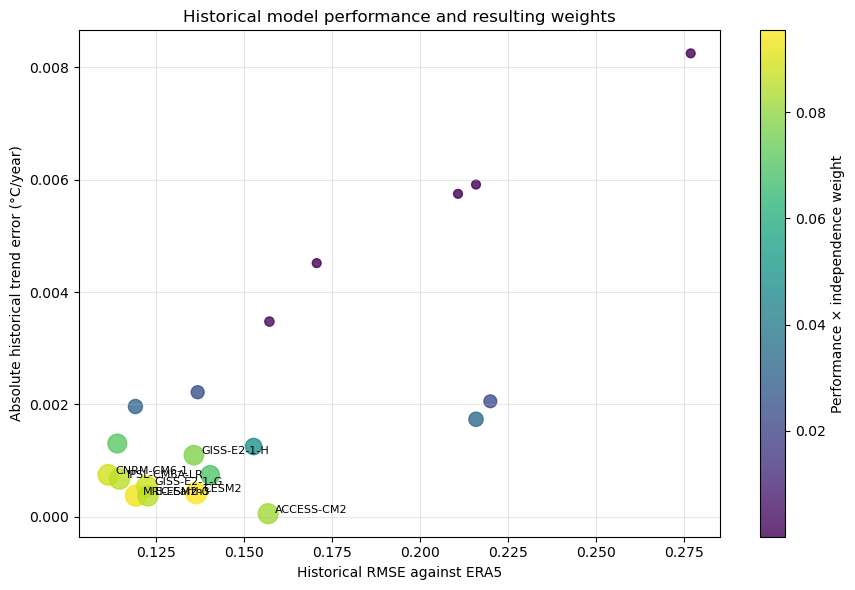

In [222]:
# Make a plotting dataframe
plot_df = diagnostics_future.copy().reset_index().rename(columns={"index": "Model"})
plot_df["abs_trend_error"] = plot_df["trend_error"].abs()

plt.figure(figsize=(9, 6))

sc = plt.scatter(
    plot_df["rmse_hist"],
    plot_df["abs_trend_error"],
    s=2000 * plot_df["w_perf_x_ind"] + 40,   # bubble size = final weight
    c=plot_df["w_perf_x_ind"],               # color = final weight
    alpha=0.8
)

# label the most important models
top_models = plot_df.sort_values("w_perf_x_ind", ascending=False).head(8)
for _, row in top_models.iterrows():
    plt.text(
        row["rmse_hist"] + 0.002,
        row["abs_trend_error"] + 0.00002,
        row["Model"],
        fontsize=8
    )

plt.xlabel("Historical RMSE against ERA5")
plt.ylabel("Absolute historical trend error (°C/year)")
plt.title("Historical model performance and resulting weights")
cbar = plt.colorbar(sc)
cbar.set_label("Performance × independence weight")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

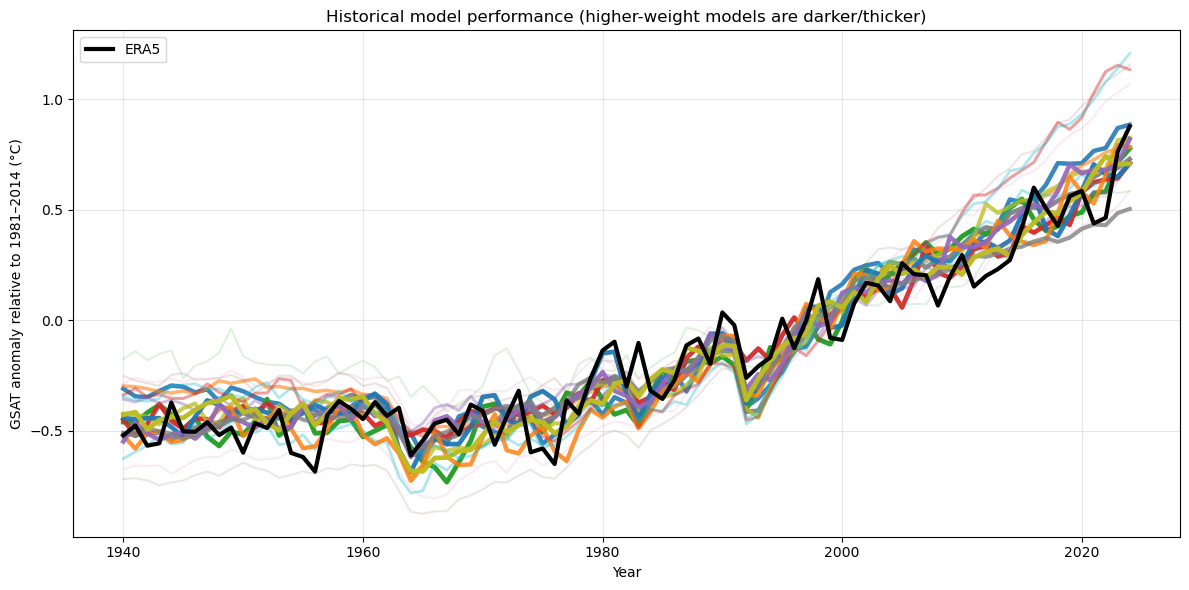

In [223]:
hist_plot = get_model_matrix(ensemble_mean, 1940, 2024)

# normalize weights to [0,1] for line alpha
w = weights_future["perf_x_independence"].reindex(hist_plot.columns)
w_scaled = (w - w.min()) / (w.max() - w.min() + 1e-12)

plt.figure(figsize=(12, 6))

# plot all models, with stronger opacity for higher-weight models
for model in hist_plot.columns:
    plt.plot(
        hist_plot.index,
        hist_plot[model],
        alpha=0.15 + 0.85 * w_scaled.loc[model],
        linewidth=1.5 + 2.0 * w_scaled.loc[model]
    )

# observations
plt.plot(
    df_era5["Year"],
    df_era5["Anomaly"],
    color="black",
    linewidth=3,
    label="ERA5"
)

plt.xlabel("Year")
plt.ylabel("GSAT anomaly relative to 1981–2014 (°C)")
plt.title("Historical model performance (higher-weight models are darker/thicker)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

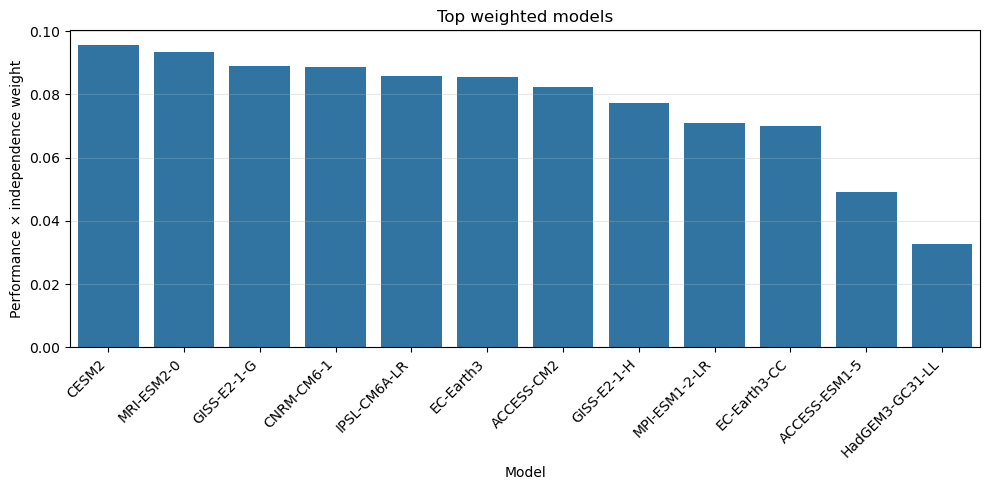

In [224]:
top_weight_df = (
    diagnostics_future["w_perf_x_ind"]
    .sort_values(ascending=False)
    .head(12)
    .reset_index()
    .rename(columns={"index": "Model", "w_perf_x_ind": "Weight"})
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_weight_df, x="Model", y="Weight")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Performance × independence weight")
plt.title("Top weighted models")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()